In [12]:
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import torch
from torch import nn
import snntorch as snn

In [2]:
import seaborn as sns
sns.set(style="whitegrid")


def pretty_plot_results(times, potentials, intensities, spikes, title="Simulation"):
    import numpy as _np
    times = _np.array(times)
    times_ms = times * 1000.0
    potentials = _np.array(potentials)
    intensities = _np.array(intensities)
    spikes = _np.array(spikes)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pal = sns.color_palette("deep")
    color_p = pal[0]
    color_i = pal[1]

    ax.plot(times_ms, potentials, color=color_p,
            lw=1.6, label="Membrane potential")
    ax.set_ylabel("Potential", color=color_p)
    ax.set_xlabel("Time (ms)")
    ax.tick_params(axis="y", labelcolor=color_p)

    ax2 = ax.twinx()
    ax2.fill_between(times_ms, intensities, color=color_i, alpha=0.25)
    ax2.plot(times_ms, intensities, color=color_i,
             lw=1.0, alpha=0.9, label="Intensity")
    ax2.set_ylabel("Intensity", color=color_i)
    ax2.tick_params(axis="y", labelcolor=color_i)

    # Plot spikes as vertical markers (raster-like) aligned to potential axis
    spike_times = times_ms[spikes.astype(
        bool)] if spikes.size else _np.array([])
    if spike_times.size > 0:
        ylim = ax.get_ylim()
        height = ylim[1] - ylim[0]
        line_y = ylim[0] + 0.85 * height
        ax.vlines(spike_times, line_y - 0.02 * height, line_y +
                  0.02 * height, color="red", alpha=0.9, linewidth=1.2)
        ax.scatter(spike_times, _np.ones_like(spike_times) * (line_y +
                   0.04 * height), color="red", s=18, zorder=5, label="Spikes")

    # Combined legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [3]:
lif = snn.Leaky(beta=0.95)

In [4]:
STEP_SIZE = 1e-3  # s
SIMULATION_LENGTH = 1  # s
REFRACTORY_PERIOD = 5  # steps

times = torch.arange(0, SIMULATION_LENGTH, STEP_SIZE)
delta_time = times[1] - times[0]
n_steps = times.shape[0]

In [ ]:
WINDOW_START = int(times.shape[0] * 0.4)
WINDOW_END = int(times.shape[0] * 0.6)

AMPLITUDE = 1.0
# Create a single step pulse as the input current
input_impulse = np.zeros_like(times)
input_impulse[WINDOW_START:WINDOW_END] = AMPLITUDE

spiked_signal = input_impulse

spiked_signal = torch.from_numpy(spiked_signal)

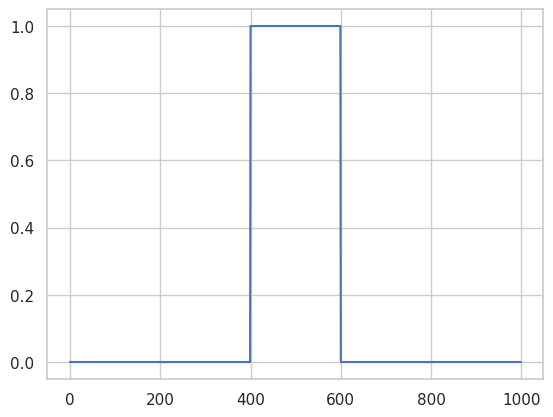

In [9]:
plt.plot(spiked_signal)

/tmp/ipykernel_65263/373564523.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  times = _np.array(times)
/tmp/ipykernel_65263/373564523.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  potentials = _np.array(potentials)
/tmp/ipykernel_65263/373564523.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  intensities = _np.array(intensities)
/tmp/ipykernel_65263/373564523.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  spikes = _np.array(spikes)


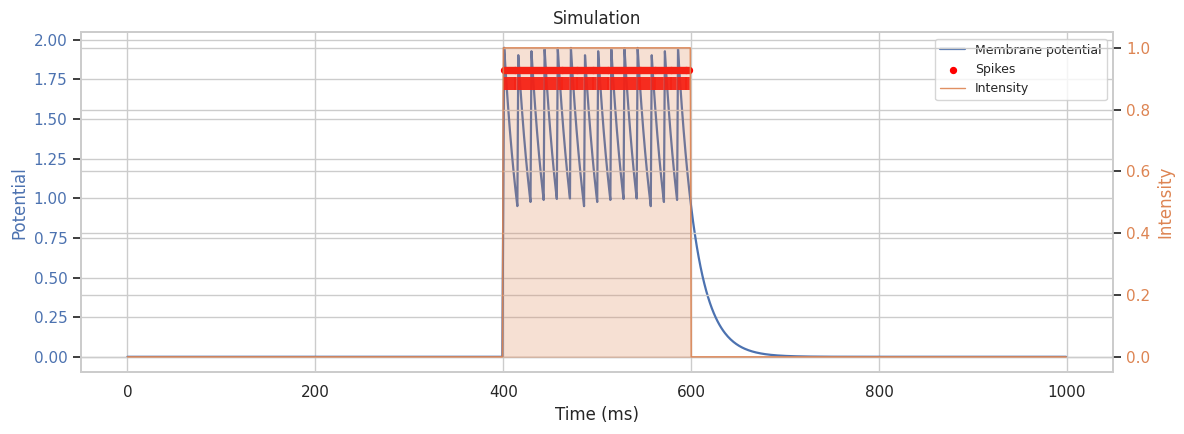

In [11]:
REST_POTENTIAL = 0

potentials = torch.zeros_like(times)
spikes = torch.zeros_like(times)

potential = torch.zeros(1)
input_current = torch.zeros(1)
spike = torch.zeros(0)


for i, t in enumerate(times):
    input_current[0] = spiked_signal[i]

    spike, potential = lif(input_current, potential)
    potentials[i] = potential[0]
    spikes[i] = spike[0]

pretty_plot_results(times, potentials, spiked_signal, spikes)